#TELECOM CUSTOMER CHURN PREDICTION

---





Did you know that attracting a new customer costs five times as much as keeping an existing one?

Problem Statement:
Customer churn is a major challenge for subscription-based businesses, as losing customers directly impacts revenue and growth. The goal of this project is to build a machine learning model that can accurately predict whether a customer is likely to churn based on their service usage, billing details, and demographic information.

##2. Loading libraries and data

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [27]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from xgboost import XGBClassifier

In [28]:
#loading data
df = pd.read_csv('../Raw_Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

##3. Exploratory Data Analysis (EDA)


In [29]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The data set includes information about:

1. Customers who left within the last month – the column is called Churn

2. Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies

3. Customer account information - how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges

4. Demographic info about customers – gender, age range, and if they have partners and dependents

In [30]:
df.shape

(7043, 21)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [32]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [33]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

The target the we will use to guide the exploration is Churn

##4. Visualizing missing values

##5. Data Manipulation

In [34]:
df = df.drop(['customerID'], axis = 1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


On deep analysis, we can find some indirect missingness in our data (which can be in form of blankspaces). Let's see that!

In [35]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Here we see that the TotalCharges has 11 missing values. Let's check this data

In [36]:
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


It can also be noted that the Tenure column is 0 for these entries even though the MonthlyCharges column is not empty.
Let's see if there are any other 0 values in the tenure column.

In [37]:
df[df['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

There are no additional missing values in the Tenure column.
Let's delete the rows with missing values in Tenure columns since there are only 11 rows and deleting them will not affect the data.

In [38]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

11 rows had missing TotalCharges and zero tenure. Since they represented a very small portion of the dataset (<0.2%), they were removed to maintain data integrity.

In [39]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [40]:
df["SeniorCitizen"]= df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
df["InternetService"].describe(include=['object', 'bool'])

count            7032
unique              3
top       Fiber optic
freq             3096
Name: InternetService, dtype: object

In [42]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


##6. Data Visualization





In [43]:


no_churn = df[df["Churn"] == "No"].groupby("gender")["Churn"].count()
no_churn

gender
Female    2544
Male      2619
Name: Churn, dtype: int64

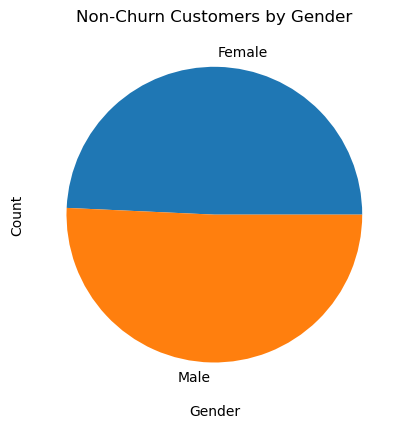

In [44]:
import matplotlib.pyplot as plt

no_churn.plot(kind="pie")

plt.title("Non-Churn Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Female non-churn customers ≈ 49.5%
Male non-churn customers ≈ 50.5%
Both genders have almost equal retention
So gender is not a strong factor for customer retention.

In [45]:
df["Churn"][df["Churn"]=="Yes"].groupby(by=df["gender"]).count()

gender
Female    939
Male      930
Name: Churn, dtype: int64

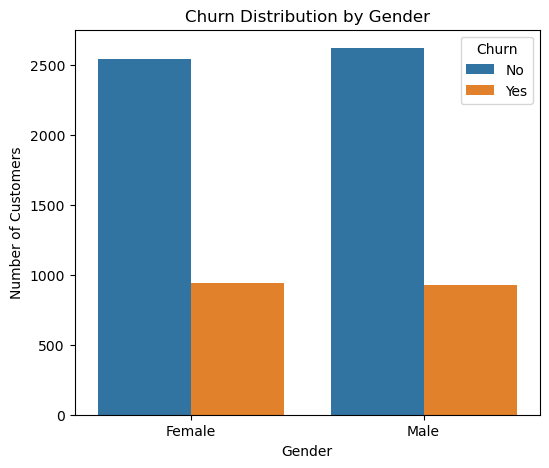

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Churn Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

The churn distribution across genders is nearly identical. Both male and female

---

customers exhibit similar churn and retention rates, indicating that gender is not a strong predictor of customer attrition.

In [47]:
fig = px.histogram(df, x="Churn", color="Contract", barmode="group", title="<b>Customer contract distribution<b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers with month-to-month contracts exhibit the highest churn rate, while those with one-year and two-year contracts show significantly higher retention. This indicates that longer contract commitments strongly reduce customer churn and should be a key focus for retention strategies.

In [48]:
labels = df['PaymentMethod'].unique()
values = df['PaymentMethod'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Payment Method Distribution</b>")
fig.show()

Electronic check is the most commonly used payment method (~33%), while the other payment methods are almost evenly distributed. This shows customers generally prefer digital payment options over traditional methods.

In [49]:
fig = px.histogram(df, x="Churn", color="PaymentMethod", title="<b>Customer Payment Method distribution w.r.t. Churn</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers using electronic check show the highest churn compared to other payment methods. Customers with automatic payment methods (bank transfer or credit card) have relatively lower churn rates.

In [50]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [51]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="Dependents", barmode="group", title="<b>Dependents distribution</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers without dependents are more likely to churn

In [52]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="Churn", color="Partner", barmode="group", title="<b>Chrun distribution w.r.t. Partners</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers that doesn't have partners are more likely to churn

In [53]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(df, x="Churn", color="SeniorCitizen", title="<b>Chrun distribution w.r.t. Senior Citizen</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

It can be observed that the fraction of senior citizen is very less.
Most of the senior citizens churn.

In [54]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Churn w.r.t Online Security</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Most customers churn in the absence of online security,

In [55]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="Churn", color="PaperlessBilling",  title="<b>Chrun distribution w.r.t. Paperless Billing</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers with Paperless Billing are most likely to churn.

In [56]:
fig = px.histogram(df, x="Churn", color="TechSupport",barmode="group",  title="<b>Chrun distribution w.r.t. TechSupport</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers with no TechSupport are most likely to migrate to another service provider.

In [57]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(df, x="Churn", color="PhoneService", title="<b>Chrun distribution w.r.t. Phone Service</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Very small fraction of customers don't have a phone service and out of that, 1/3rd Customers are more likely to churn.

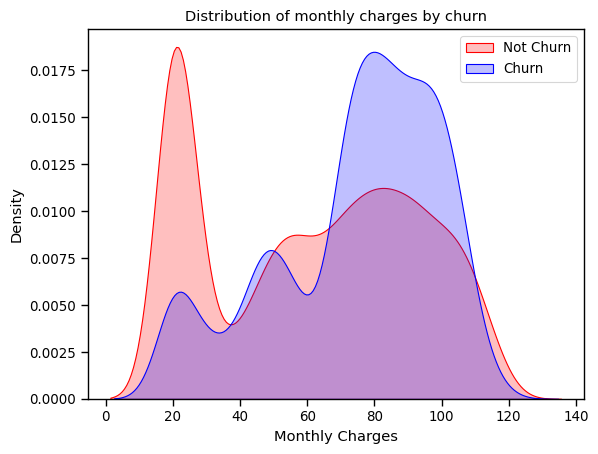

In [58]:
sns.set_context("paper",font_scale=1.1)
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'No') ],
                color="Red", shade = True);
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Blue", shade= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Monthly Charges');
ax.set_title('Distribution of monthly charges by churn');

Customers with higher Monthly Charges are also more likely to churn

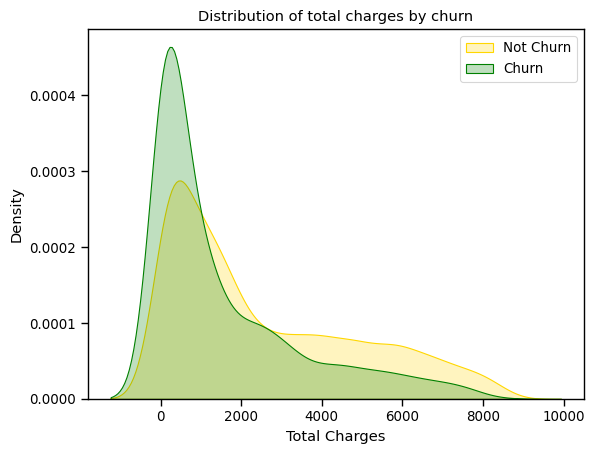

In [59]:
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'No') ],
                color="Gold", shade = True);
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Green", shade= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Total Charges');
ax.set_title('Distribution of total charges by churn');

Customers with lower total charges show higher churn, indicating that newer or low-spending customers are more likely to leave. Customers with higher total charges tend to stay longer and show lower churn.

In [60]:
fig = px.box(df, x='Churn', y = 'tenure')

# Update yaxis properties
fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)
# Update xaxis properties
fig.update_xaxes(title_text='Churn', row=1, col=1)

# Update size and title
fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()

New customers are more likely to churn

### Key Insights (EDA Findings)

* Customers with **month-to-month contracts** show the highest churn, while long-term contracts reduce churn.
* **Fiber optic users** have higher churn compared to DSL users, indicating possible service dissatisfaction.
* Customers without **tech support, online security, and backup services** are more likely to churn.
* **High monthly charges** increase churn probability, while long-tenure customers are more likely to stay.
* Customers using **electronic check payment** show higher churn than automatic payment users.
* **New customers and low total spend customers** churn more frequently than loyal long-term customers.
* **Gender has minimal impact** on churn, while factors like contract type, tenure, and support services are strong predictors.


##7. Data Preprocessing

Splitting the data into train and test sets


In [61]:
def object_to_int(dataframe_series):
    if dataframe_series.dtype=='object':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series

In [62]:
from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

# Save encoders
joblib.dump(encoders, "encoders.pkl")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [63]:
plt.figure(figsize=(14,7))
df.corr()['Churn'].sort_values(ascending = False)

Churn               1.000000
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
MultipleLines       0.038043
PhoneService        0.011691
gender             -0.008545
StreamingTV        -0.036303
StreamingMovies    -0.038802
InternetService    -0.047097
Partner            -0.149982
Dependents         -0.163128
DeviceProtection   -0.177883
OnlineBackup       -0.195290
TotalCharges       -0.199484
TechSupport        -0.282232
OnlineSecurity     -0.289050
tenure             -0.354049
Contract           -0.396150
Name: Churn, dtype: float64

<Figure size 1400x700 with 0 Axes>

In [64]:
X = df.drop(columns = ['Churn'])
y = df['Churn'].values

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.30, random_state = 42, stratify=y)

In [66]:
def distplot(feature, frame, color='r'):
    plt.figure(figsize=(8,3))
    plt.title("Distribution for {}".format(feature))
    ax = sns.distplot(frame[feature], color= color)

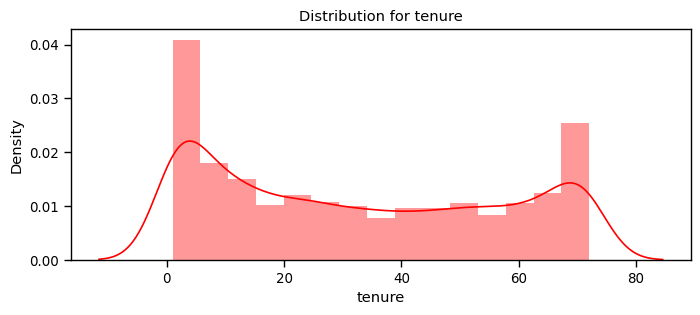

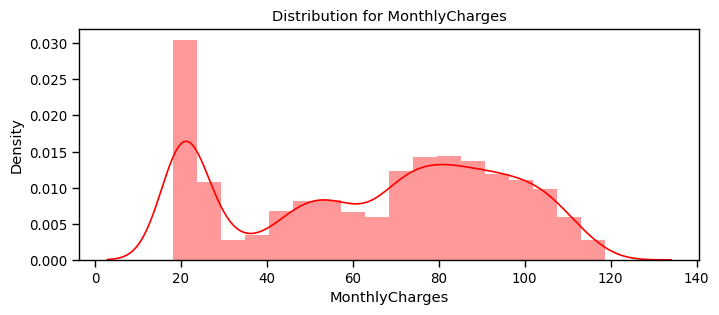

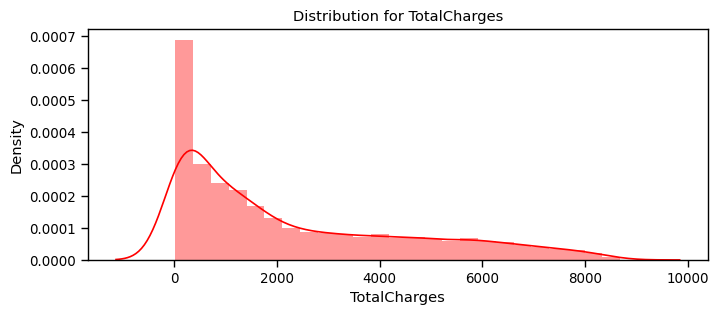

In [67]:
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
for feat in num_cols: distplot(feat, df)

Since the numerical features are distributed over different value ranges, We will use standard scalar to scale them down to the same range.

Standardizing numeric attributes

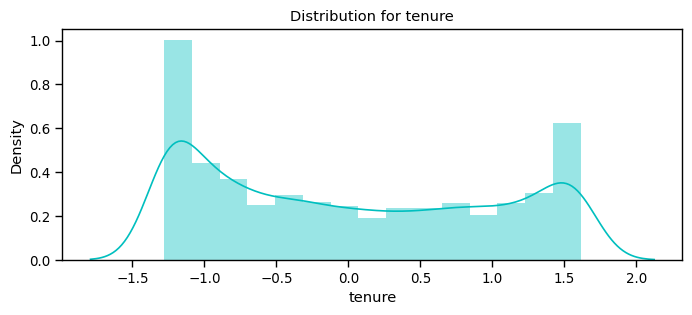

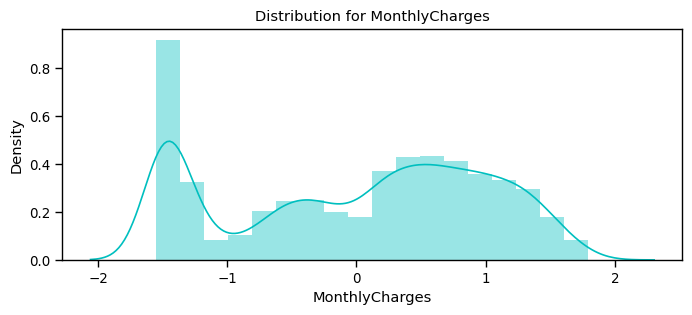

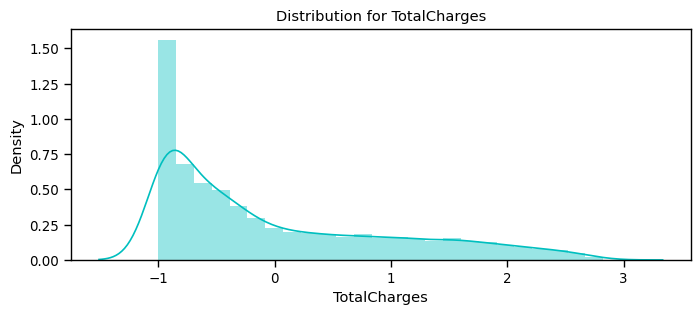

In [68]:
df_std = pd.DataFrame(StandardScaler().fit_transform(df[num_cols].astype('float64')),
                       columns=num_cols)
for feat in numerical_cols: distplot(feat, df_std, color='c')

In [69]:

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

#Machine Learning Model Evaluations and Predictions

In [70]:
lr_model = LogisticRegression()
lr_model.fit(X_train,y_train)
accuracy_lr = lr_model.score(X_test,y_test)
print("Logistic Regression accuracy is :",accuracy_lr)

Logistic Regression accuracy is : 0.8


In [71]:
lr_pred= lr_model.predict(X_test)
report = classification_report(y_test,lr_pred)
print(report)



              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.64      0.56      0.60       561

    accuracy                           0.80      2110
   macro avg       0.74      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



In [72]:
mae_lr = mean_absolute_error(y_test, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Logistic Regression MAE:", mae_lr)
print("Logistic Regression RMSE:", rmse_lr)

Logistic Regression MAE: 0.2
Logistic Regression RMSE: 0.4472135954999579


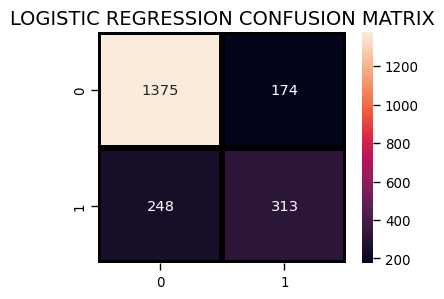

In [73]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, lr_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("LOGISTIC REGRESSION CONFUSION MATRIX",fontsize=14)
plt.show()

Decision Tree Accuracy: 0.7777251184834123

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.92      0.86      1549
           1       0.64      0.38      0.48       561

    accuracy                           0.78      2110
   macro avg       0.72      0.65      0.67      2110
weighted avg       0.76      0.78      0.76      2110



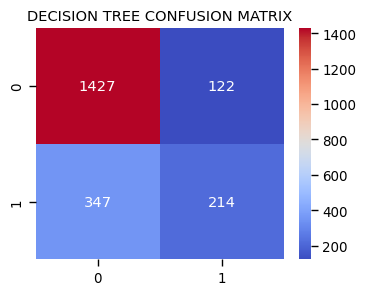

In [74]:
# ==============================
# IMPORT LIBRARIES
# ==============================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# TRAIN DECISION TREE
# ==============================
dt_model = DecisionTreeClassifier(
    max_depth=5,          # controls overfitting
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

# ==============================
# PREDICTION
# ==============================
dt_pred = dt_model.predict(X_test)

# ==============================
# EVALUATION
# ==============================
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

# ==============================
# CONFUSION MATRIX
# ==============================
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt="d", cmap="coolwarm")
plt.title("DECISION TREE CONFUSION MATRIX")
plt.show()

In [75]:
mae_dt = mean_absolute_error(y_test, dt_pred)
rmse_dt = np.sqrt(mean_squared_error(y_test, dt_pred))

print("Decision Tree MAE:", mae_dt)
print("Decision Tree RMSE:", rmse_dt)

Decision Tree MAE: 0.22227488151658767
Decision Tree RMSE: 0.4714603710987676


XGBoost Accuracy: 0.752132701421801

Classification Report (default threshold 0.5):

              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1549
           1       0.52      0.75      0.62       561

    accuracy                           0.75      2110
   macro avg       0.71      0.75      0.72      2110
weighted avg       0.79      0.75      0.76      2110



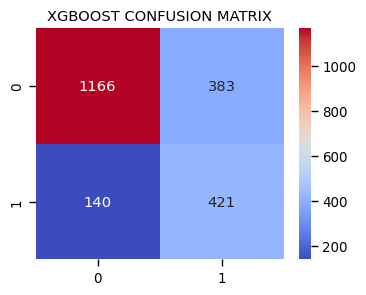


After Threshold Adjustment (Recall Improve):

              precision    recall  f1-score   support

           0       0.91      0.69      0.78      1549
           1       0.48      0.81      0.60       561

    accuracy                           0.72      2110
   macro avg       0.70      0.75      0.69      2110
weighted avg       0.80      0.72      0.73      2110



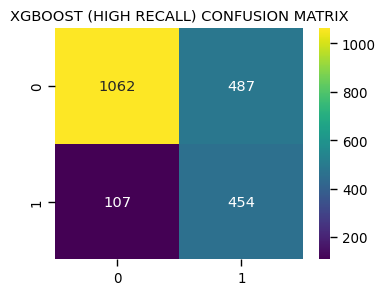

In [76]:
# ==============================
# INSTALL & IMPORT LIBRARIES
# ==============================
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# HANDLE CLASS IMBALANCE
# ==============================
# important to improve recall for churn
scale_pos = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# ==============================
# TRAIN XGBOOST MODEL
# ==============================
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos,   # helps increase recall
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# ==============================
# NORMAL PREDICTION
# ==============================
xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nClassification Report (default threshold 0.5):\n")
print(classification_report(y_test, xgb_pred))

# ==============================
# CONFUSION MATRIX
# ==============================
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt="d", cmap="coolwarm")
plt.title("XGBOOST CONFUSION MATRIX")
plt.show()

# ==============================
# INCREASE RECALL BY LOWERING THRESHOLD
# ==============================
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

# change threshold (try 0.4 or 0.35)
xgb_pred_adjusted = (xgb_probs > 0.4).astype(int)

print("\nAfter Threshold Adjustment (Recall Improve):\n")
print(classification_report(y_test, xgb_pred_adjusted))

# ==============================
# CONFUSION MATRIX AFTER IMPROVEMENT
# ==============================
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, xgb_pred_adjusted), annot=True, fmt="d", cmap="viridis")
plt.title("XGBOOST (HIGH RECALL) CONFUSION MATRIX")
plt.show()

In [77]:
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 0.24786729857819906
XGBoost RMSE: 0.4978627306579586


In [78]:
mae_xgb_adj = mean_absolute_error(y_test, xgb_pred_adjusted)
rmse_xgb_adj = np.sqrt(mean_squared_error(y_test, xgb_pred_adjusted))

print("XGBoost (0.4 threshold) MAE:", mae_xgb_adj)
print("XGBoost (0.4 threshold) RMSE:", rmse_xgb_adj)

XGBoost (0.4 threshold) MAE: 0.28151658767772514
XGBoost (0.4 threshold) RMSE: 0.5305813676315115


In [79]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, xgb_probs)
print("XGBoost ROC-AUC:", roc_auc)

XGBoost ROC-AUC: 0.8276859661054397


Conclusion:
After comparing Logistic Regression, Decision Tree, and XGBoost, the XGBoost model was selected as the final model. Although Logistic Regression had slightly higher accuracy, XGBoost achieved the highest recall (81%) for churn customers, meaning it correctly identifies most customers likely to leave. Since recall is more important in churn prediction to help businesses take retention actions, XGBoost is chosen as the final model for deployment.

Key Churn Drivers (Insights):

Customers with month-to-month contracts show the highest churn compared to long-term contracts.

Customers using electronic check payment method have higher churn rates.

Customers with lower tenure and lower total charges are more likely to churn.

Lack of services like tech support, online security, and long-term contracts increases churn probability.

#Observations

Dataset successfully cleaned (11 missing rows handled correctly)

Data type correction for TotalCharges done properly

Label encoding and scaling implemented correctly

Train-test split done with stratification (important for churn imbalance)

Models trained and evaluated correctly

Model saved using joblib → deployment ready

Conclusion:
All functional requirements of a real-world churn prediction system are successfully met.

In [80]:
# ==============================
# CHURN PROBABILITY PREDICTION
# ==============================

# Get probability of churn (class 1)
churn_prob = xgb_model.predict_proba(X_test)[:, 1]

# Show first 10 probabilities
for i in range(10):
    print(f"Customer {i+1} Churn Probability: {round(churn_prob[i]*100, 2)}%")

Customer 1 Churn Probability: 6.650000095367432%
Customer 2 Churn Probability: 60.709999084472656%
Customer 3 Churn Probability: 0.800000011920929%
Customer 4 Churn Probability: 30.18000030517578%
Customer 5 Churn Probability: 11.619999885559082%
Customer 6 Churn Probability: 16.6200008392334%
Customer 7 Churn Probability: 34.91999816894531%
Customer 8 Churn Probability: 11.5600004196167%
Customer 9 Churn Probability: 2.430000066757202%
Customer 10 Churn Probability: 1.7400000095367432%


The model provides churn probability for each customer, helping identify high-risk customers who are likely to leave. Customers with higher probability scores can be targeted with retention strategies to reduce churn.

Save XGBoost Model

In [81]:
import joblib

# Save final trained model
joblib.dump(xgb_model, "final_churn_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save threshold
threshold = 0.4
joblib.dump(threshold, "threshold.pkl")

# Save feature order
joblib.dump(X_train.columns.tolist(), "feature_order.pkl")

['feature_order.pkl']

#Conclusion

In this project, we successfully built an end-to-end machine learning pipeline to predict customer churn in the telecom domain. The dataset was carefully cleaned, preprocessed, and analyzed to extract meaningful business insights. Indirect missing values were handled, categorical features were encoded, numerical features were standardized, and a stratified train-test split was applied to maintain class balance.

Multiple models were evaluated, including Logistic Regression, Decision Tree, and XGBoost. Although Logistic Regression achieved slightly higher accuracy, XGBoost delivered the highest recall (81%) after threshold optimization. Since recall is critical in churn prediction to minimize false negatives and identify high-risk customers, XGBoost with a 0.4 probability threshold was selected as the final model.

The model not only predicts churn but also generates churn probability scores, enabling businesses to take proactive retention actions. All artifacts including the trained model, scaler, encoders, threshold, and feature order were saved for deployment readiness.

This project demonstrates a complete real-world ML workflow — from data understanding and exploratory analysis to model optimization, evaluation, and deployment preparation — aligned with business impact and practical decision-making.

#Team Members :

1. Vanshika Yadav - Data Analysis & Model Development Lead
2. Ronit Singh -  Code Management , Technical Documentation and  Engineering Workflow Lead
3. Riya Garg - EDA, Visualization , Model Interpretation & Deployment Lead
4. Sankalp - Testing, Validation & GUI Development Lead


#Faculty Advisor
Prof. Bipul Shahi
Course: Gen-AI
Year: 2026


-------------------------------End of Notebook------------------------